# SIFT Part 4: Descriptor Generation

## The Final Piece

We now have keypoints with:
- **Location** (x, y) - where the feature is
- **Scale** (σ) - how big the feature is
- **Orientation** (θ) - which way it points

Now we need a **descriptor** - a numerical fingerprint that:
1. Uniquely identifies this specific feature
2. Is similar for the same feature in different images
3. Is different for different features

## The SIFT Descriptor: 128 Numbers

SIFT creates a 128-dimensional vector (128 numbers) that describes the local gradient structure around each keypoint.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Import functions from previous notebooks
def gaussian_kernel_1d(sigma, size=None):
    if size is None:
        size = int(np.ceil(6 * sigma))
        if size % 2 == 0:
            size += 1
    x = np.arange(size) - size // 2
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / kernel.sum()

def gaussian_blur(image, sigma):
    kernel = gaussian_kernel_1d(sigma)
    pad = len(kernel) // 2
    padded = np.pad(image, pad, mode='reflect')
    temp = np.zeros_like(padded, dtype=np.float64)
    for i in range(len(kernel)):
        temp[:, pad:-pad] += kernel[i] * padded[:, i:i+image.shape[1]]
    result = np.zeros_like(image, dtype=np.float64)
    for i in range(len(kernel)):
        result += kernel[i] * temp[i:i+image.shape[0], pad:-pad]
    return result

def compute_gradients(image):
    dx = np.zeros_like(image)
    dx[:, 1:-1] = image[:, 2:] - image[:, :-2]
    dy = np.zeros_like(image)
    dy[1:-1, :] = image[2:, :] - image[:-2, :]
    magnitude = np.sqrt(dx**2 + dy**2)
    orientation = np.rad2deg(np.arctan2(dy, dx)) % 360
    return magnitude, orientation

In [2]:
# Load test image
examples_path = Path('../../Examples')
test_images = list(examples_path.glob('*.jpg')) + list(examples_path.glob('*.png'))

if test_images:
    img = cv2.imread(str(test_images[0]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (400, 400))
else:
    img = np.ones((400, 400), dtype=np.uint8) * 255
    for i in range(0, 401, 44):
        img[i:i+2, :] = 0
        img[:, i:i+2] = 0

img_float = img.astype(np.float64) / 255.0

## 1. The Descriptor Structure

### 4×4 Grid of Histograms

SIFT divides the region around a keypoint into a **4×4 grid** of subregions:

```
    ┌───┬───┬───┬───┐
    │ 0 │ 1 │ 2 │ 3 │
    ├───┼───┼───┼───┤
    │ 4 │ 5 │ 6 │ 7 │
    ├───┼───┼───┼───┤
    │ 8 │ 9 │10 │11 │
    ├───┼───┼───┼───┤
    │12 │13 │14 │15 │
    └───┴───┴───┴───┘
           ↑
      Keypoint at center
```

### 8-Bin Orientation Histogram per Subregion

Each subregion gets an **8-bin histogram** (45° per bin):

```
    Bin 0: 0° - 45°    (→)
    Bin 1: 45° - 90°   (↗)
    Bin 2: 90° - 135°  (↑)
    ...
    Bin 7: 315° - 360° (↘)
```

### Total: 4 × 4 × 8 = 128 Dimensions

Each of the 16 subregions contributes 8 values = 128 total.

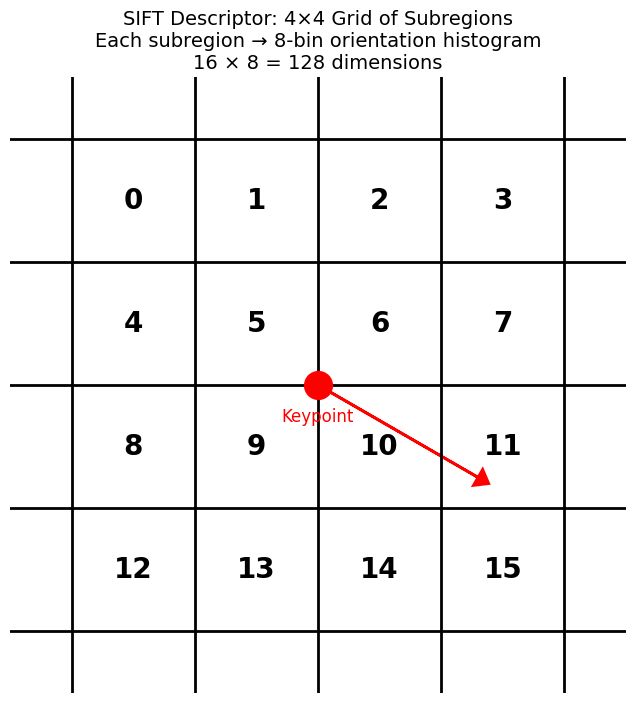

In [3]:
# Visualize the 4x4 grid structure
fig, ax = plt.subplots(figsize=(8, 8))

# Draw grid
for i in range(5):
    ax.axhline(i, color='black', linewidth=2)
    ax.axvline(i, color='black', linewidth=2)

# Label cells
for row in range(4):
    for col in range(4):
        cell_num = row * 4 + col
        ax.text(col + 0.5, row + 0.5, str(cell_num), 
                ha='center', va='center', fontsize=20, fontweight='bold')

# Draw keypoint at center
ax.plot(2, 2, 'ro', markersize=20)
ax.text(2, 2.3, 'Keypoint', ha='center', fontsize=12, color='red')

# Draw orientation (example: 30°)
theta = np.deg2rad(30)
ax.arrow(2, 2, 1.5*np.cos(theta), 1.5*np.sin(theta),
         head_width=0.15, head_length=0.1, fc='red', ec='red', linewidth=2)

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(4.5, -0.5)
ax.set_aspect('equal')
ax.set_title('SIFT Descriptor: 4×4 Grid of Subregions\n'
             'Each subregion → 8-bin orientation histogram\n'
             '16 × 8 = 128 dimensions', fontsize=14)
ax.axis('off')
plt.show()

## 2. Rotation Alignment

### The Key to Rotation Invariance

Before computing the descriptor, we **rotate the coordinate system** to align with the keypoint's orientation:

```
Original:               After rotation:
     ↑ y                     → aligned x'
     │                       ↑
     │   θ                   │
  ───●────→ x             ───●────→ y'
    ╱                        
   ╱ orientation              
```

### Rotating Sample Coordinates

For each sample point relative to keypoint:

$$x' = (x - kp_x) \cos\theta + (y - kp_y) \sin\theta$$
$$y' = -(x - kp_x) \sin\theta + (y - kp_y) \cos\theta$$

### Rotating Gradient Orientations

Gradient angles are measured relative to keypoint orientation:

$$\theta_{relative} = \theta_{gradient} - \theta_{keypoint}$$

In [4]:
def rotate_point(x, y, center_x, center_y, angle_rad):
    """
    Rotate a point around a center by angle_rad radians.
    
    Returns rotated (x', y') coordinates.
    """
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    # Translate to origin
    dx = x - center_x
    dy = y - center_y
    
    # Rotate
    x_rot = dx * cos_a + dy * sin_a
    y_rot = -dx * sin_a + dy * cos_a
    
    return x_rot, y_rot

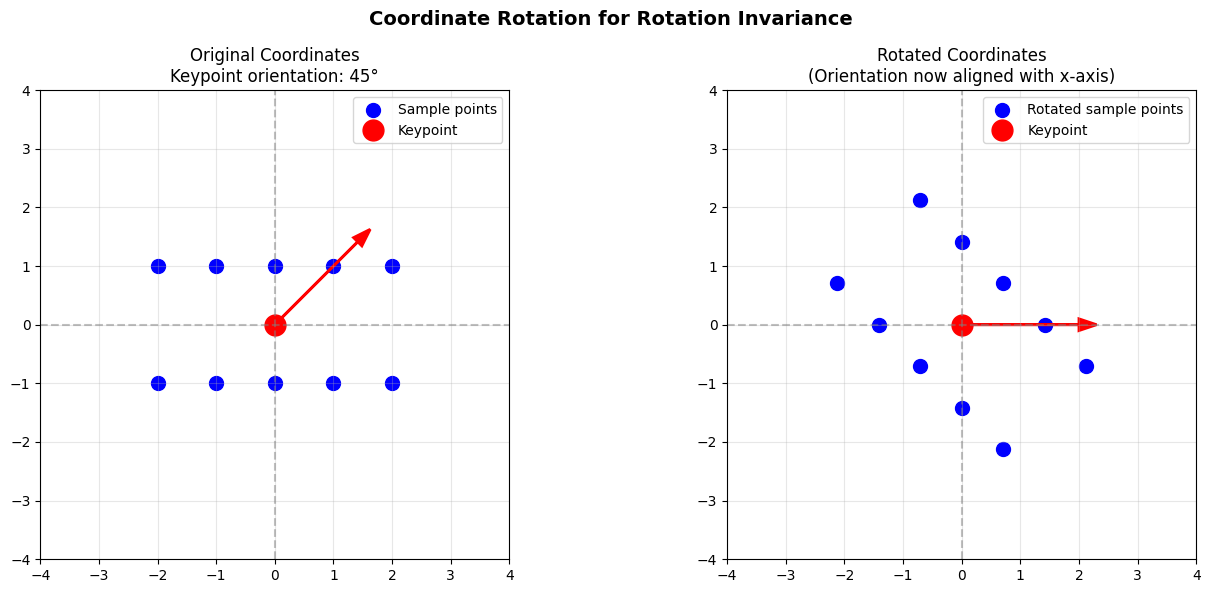

In [5]:
# Visualize coordinate rotation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sample points in a grid
points_x = np.array([-2, -1, 0, 1, 2, -2, -1, 0, 1, 2])
points_y = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1, -1])

# Keypoint at origin with 45° orientation
kp_orientation = 45  # degrees
theta = np.deg2rad(kp_orientation)

# Left: original coordinates
axes[0].scatter(points_x, points_y, s=100, c='blue', label='Sample points')
axes[0].plot(0, 0, 'ro', markersize=15, label='Keypoint')
axes[0].arrow(0, 0, 2*np.cos(theta), 2*np.sin(theta),
              head_width=0.2, fc='red', ec='red', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(-4, 4)
axes[0].set_aspect('equal')
axes[0].set_title(f'Original Coordinates\nKeypoint orientation: {kp_orientation}°')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: rotated coordinates
rotated_x, rotated_y = rotate_point(points_x, points_y, 0, 0, theta)
axes[1].scatter(rotated_x, rotated_y, s=100, c='blue', label='Rotated sample points')
axes[1].plot(0, 0, 'ro', markersize=15, label='Keypoint')
axes[1].arrow(0, 0, 2, 0, head_width=0.2, fc='red', ec='red', linewidth=2)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlim(-4, 4)
axes[1].set_ylim(-4, 4)
axes[1].set_aspect('equal')
axes[1].set_title('Rotated Coordinates\n(Orientation now aligned with x-axis)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Coordinate Rotation for Rotation Invariance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Gaussian Weighting

### Why Weight by Distance?

Pixels far from the keypoint:
- Are less reliable (might belong to different features)
- Should contribute less to the descriptor

### The Weighting Function

SIFT uses a Gaussian window with $\sigma = 0.5 \times $ descriptor width:

$$w(x, y) = \exp\left(-\frac{x'^2 + y'^2}{2 \sigma_w^2}\right)$$

This makes the descriptor focus on the central region while still capturing context.

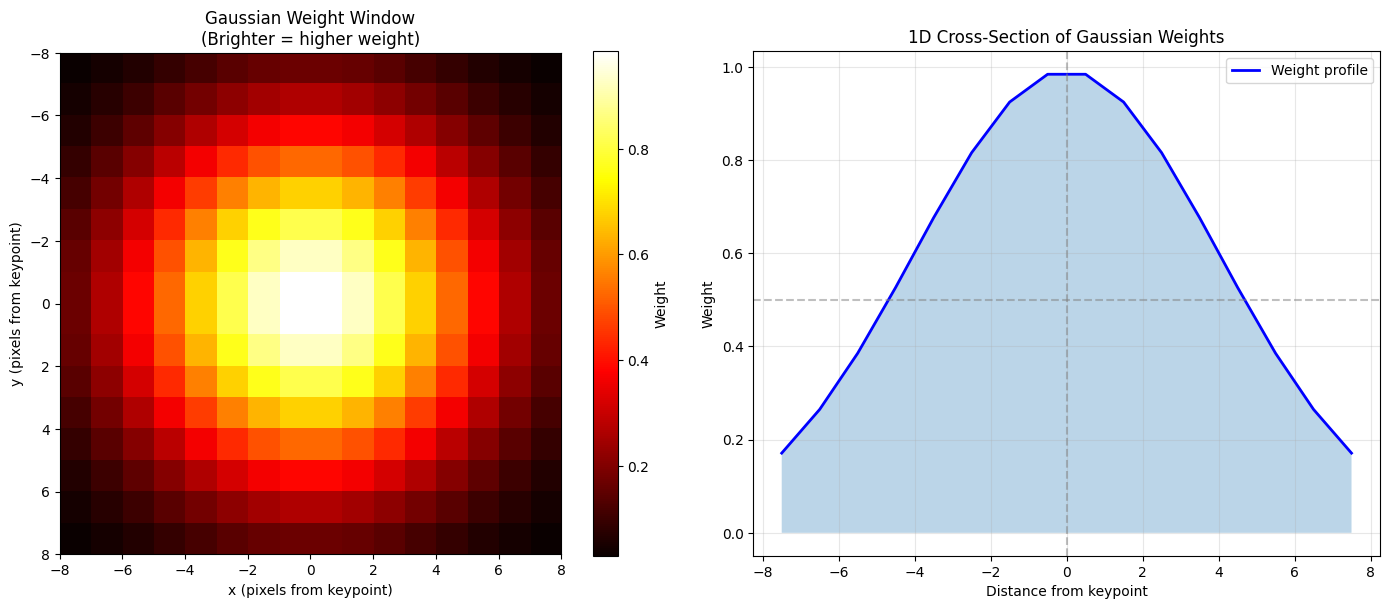

In [6]:
# Visualize Gaussian weighting
size = 16
x = np.arange(size) - size // 2 + 0.5
y = np.arange(size) - size // 2 + 0.5
X, Y = np.meshgrid(x, y)

sigma_w = size / 2 * 0.5  # Half the window width
weights = np.exp(-(X**2 + Y**2) / (2 * sigma_w**2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2D view
im = axes[0].imshow(weights, cmap='hot', extent=[-8, 8, 8, -8])
axes[0].plot(0, 0, 'w+', markersize=20, markeredgewidth=3)
axes[0].set_title('Gaussian Weight Window\n(Brighter = higher weight)')
axes[0].set_xlabel('x (pixels from keypoint)')
axes[0].set_ylabel('y (pixels from keypoint)')
plt.colorbar(im, ax=axes[0], label='Weight')

# 1D cross-section
axes[1].plot(x, weights[size//2, :], 'b-', linewidth=2, label='Weight profile')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(x, 0, weights[size//2, :], alpha=0.3)
axes[1].set_xlabel('Distance from keypoint')
axes[1].set_ylabel('Weight')
axes[1].set_title('1D Cross-Section of Gaussian Weights')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Trilinear Interpolation

### The Problem with Hard Bins

If we just drop each sample into the nearest bin:
- Small changes in position → sample jumps to different bin
- Descriptor becomes unstable

### Solution: Soft Assignment

Each sample contributes to **multiple bins** based on how close it is:

1. **Spatial**: Contributes to 4 neighboring spatial bins (bilinear)
2. **Orientation**: Contributes to 2 neighboring orientation bins (linear)

Total: Each sample can affect up to 8 histogram entries!

In [7]:
def trilinear_interpolation_weights(x_bin, y_bin, ori_bin, num_spatial_bins=4, num_ori_bins=8):
    """
    Compute trilinear interpolation weights for soft histogram assignment.
    
    Args:
        x_bin, y_bin: Fractional bin positions (0 to num_spatial_bins)
        ori_bin: Fractional orientation bin (0 to num_ori_bins)
    
    Returns:
        List of (spatial_bin_idx, ori_bin_idx, weight) tuples
    """
    contributions = []
    
    # Determine the bins this sample falls between
    x0 = int(np.floor(x_bin))
    y0 = int(np.floor(y_bin))
    o0 = int(np.floor(ori_bin))
    
    # Fractional parts (how far into the bin)
    x_frac = x_bin - x0
    y_frac = y_bin - y0
    o_frac = ori_bin - o0
    
    # Iterate over 2x2x2 neighboring bins
    for dx in [0, 1]:
        for dy in [0, 1]:
            for do in [0, 1]:
                xi = x0 + dx
                yi = y0 + dy
                oi = (o0 + do) % num_ori_bins  # Orientation wraps around
                
                # Check spatial bounds
                if xi < 0 or xi >= num_spatial_bins:
                    continue
                if yi < 0 or yi >= num_spatial_bins:
                    continue
                
                # Compute weight (product of 1D linear weights)
                wx = (1 - x_frac) if dx == 0 else x_frac
                wy = (1 - y_frac) if dy == 0 else y_frac
                wo = (1 - o_frac) if do == 0 else o_frac
                
                weight = wx * wy * wo
                
                if weight > 0:
                    spatial_idx = yi * num_spatial_bins + xi
                    contributions.append((spatial_idx, oi, weight))
    
    return contributions

In [8]:
# Visualize trilinear interpolation
# Example: sample at position (1.3, 2.7) with orientation bin 3.2
x_bin, y_bin, ori_bin = 1.3, 2.7, 3.2

contributions = trilinear_interpolation_weights(x_bin, y_bin, ori_bin)

print(f"Sample at spatial bin ({x_bin}, {y_bin}), orientation bin {ori_bin}")
print(f"\nContributes to {len(contributions)} histogram entries:")
print("-" * 50)

total_weight = 0
for spatial_idx, ori_idx, weight in contributions:
    row = spatial_idx // 4
    col = spatial_idx % 4
    print(f"  Spatial bin ({col}, {row}), Ori bin {ori_idx}: weight = {weight:.3f}")
    total_weight += weight

print("-" * 50)
print(f"Total weight: {total_weight:.3f} (should be ~1.0)")

Sample at spatial bin (1.3, 2.7), orientation bin 3.2

Contributes to 8 histogram entries:
--------------------------------------------------
  Spatial bin (1, 2), Ori bin 3: weight = 0.168
  Spatial bin (1, 2), Ori bin 4: weight = 0.042
  Spatial bin (1, 3), Ori bin 3: weight = 0.392
  Spatial bin (1, 3), Ori bin 4: weight = 0.098
  Spatial bin (2, 2), Ori bin 3: weight = 0.072
  Spatial bin (2, 2), Ori bin 4: weight = 0.018
  Spatial bin (2, 3), Ori bin 3: weight = 0.168
  Spatial bin (2, 3), Ori bin 4: weight = 0.042
--------------------------------------------------
Total weight: 1.000 (should be ~1.0)


## 5. Complete Descriptor Computation

In [9]:
def compute_sift_descriptor(image, kp_x, kp_y, kp_sigma, kp_orientation,
                            num_spatial_bins=4, num_ori_bins=8, 
                            window_width=16, magnitude_threshold=0.2):
    """
    Compute SIFT descriptor for a single keypoint.
    
    Args:
        image: Grayscale image (float, 0-1)
        kp_x, kp_y: Keypoint location
        kp_sigma: Keypoint scale
        kp_orientation: Keypoint orientation (degrees)
        num_spatial_bins: Number of spatial bins per dimension (default 4)
        num_ori_bins: Number of orientation bins (default 8)
        window_width: Descriptor window width in pixels (default 16)
        magnitude_threshold: Cap on individual histogram values
    
    Returns:
        128-dimensional descriptor (normalized)
    """
    height, width = image.shape
    
    # Blur image at keypoint scale
    blurred = gaussian_blur(image, kp_sigma)
    
    # Compute gradients
    magnitude, orientation = compute_gradients(blurred)
    
    # Initialize histogram: 4x4 spatial bins, 8 orientation bins each
    histogram = np.zeros((num_spatial_bins, num_spatial_bins, num_ori_bins))
    
    # Convert orientation to radians
    theta = np.deg2rad(kp_orientation)
    
    # Gaussian weight sigma (half of window)
    sigma_w = window_width / 2 * 0.5
    
    # Size of each spatial bin
    bin_size = window_width / num_spatial_bins
    
    # Sample radius (half window, plus some margin for rotation)
    radius = int(np.ceil(window_width * np.sqrt(2) / 2))
    
    # Iterate over sample points
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            # Sample location in image
            sample_x = int(round(kp_x)) + dx
            sample_y = int(round(kp_y)) + dy
            
            # Check bounds
            if sample_x < 1 or sample_x >= width - 1:
                continue
            if sample_y < 1 or sample_y >= height - 1:
                continue
            
            # Rotate sample position relative to keypoint
            x_rot, y_rot = rotate_point(dx, dy, 0, 0, theta)
            
            # Check if within descriptor window
            if abs(x_rot) > window_width / 2 or abs(y_rot) > window_width / 2:
                continue
            
            # Compute Gaussian weight based on distance from center
            gauss_weight = np.exp(-(x_rot**2 + y_rot**2) / (2 * sigma_w**2))
            
            # Get gradient at sample point
            mag = magnitude[sample_y, sample_x]
            ori = orientation[sample_y, sample_x]
            
            # Rotate gradient orientation relative to keypoint orientation
            ori_relative = (ori - kp_orientation) % 360
            
            # Convert to bin coordinates
            # Spatial: shift so (0,0) is at corner of descriptor window
            x_bin = (x_rot + window_width / 2) / bin_size - 0.5
            y_bin = (y_rot + window_width / 2) / bin_size - 0.5
            
            # Orientation bin
            ori_bin = ori_relative / (360 / num_ori_bins)
            
            # Weighted magnitude
            weighted_mag = mag * gauss_weight
            
            # Trilinear interpolation - distribute to neighboring bins
            contributions = trilinear_interpolation_weights(
                x_bin, y_bin, ori_bin, num_spatial_bins, num_ori_bins
            )
            
            for spatial_idx, ori_idx, interp_weight in contributions:
                row = spatial_idx // num_spatial_bins
                col = spatial_idx % num_spatial_bins
                histogram[row, col, ori_idx] += weighted_mag * interp_weight
    
    # Flatten to 128-D vector
    descriptor = histogram.flatten()
    
    # Normalize to unit length
    norm = np.linalg.norm(descriptor)
    if norm > 1e-6:
        descriptor = descriptor / norm
    
    # Threshold to reduce influence of large gradients
    descriptor = np.minimum(descriptor, magnitude_threshold)
    
    # Re-normalize
    norm = np.linalg.norm(descriptor)
    if norm > 1e-6:
        descriptor = descriptor / norm
    
    return descriptor

In [10]:
# Compute descriptor for a sample keypoint
kp_x, kp_y = 100, 100
kp_sigma = 2.0
kp_orientation = 45  # degrees

descriptor = compute_sift_descriptor(img_float, kp_x, kp_y, kp_sigma, kp_orientation)

print(f"Descriptor shape: {descriptor.shape}")
print(f"Descriptor norm: {np.linalg.norm(descriptor):.4f}")
print(f"Min value: {descriptor.min():.4f}")
print(f"Max value: {descriptor.max():.4f}")
print(f"Non-zero entries: {np.sum(descriptor > 0.001)}")

Descriptor shape: (128,)
Descriptor norm: 1.0000
Min value: 0.0000
Max value: 0.4001
Non-zero entries: 18


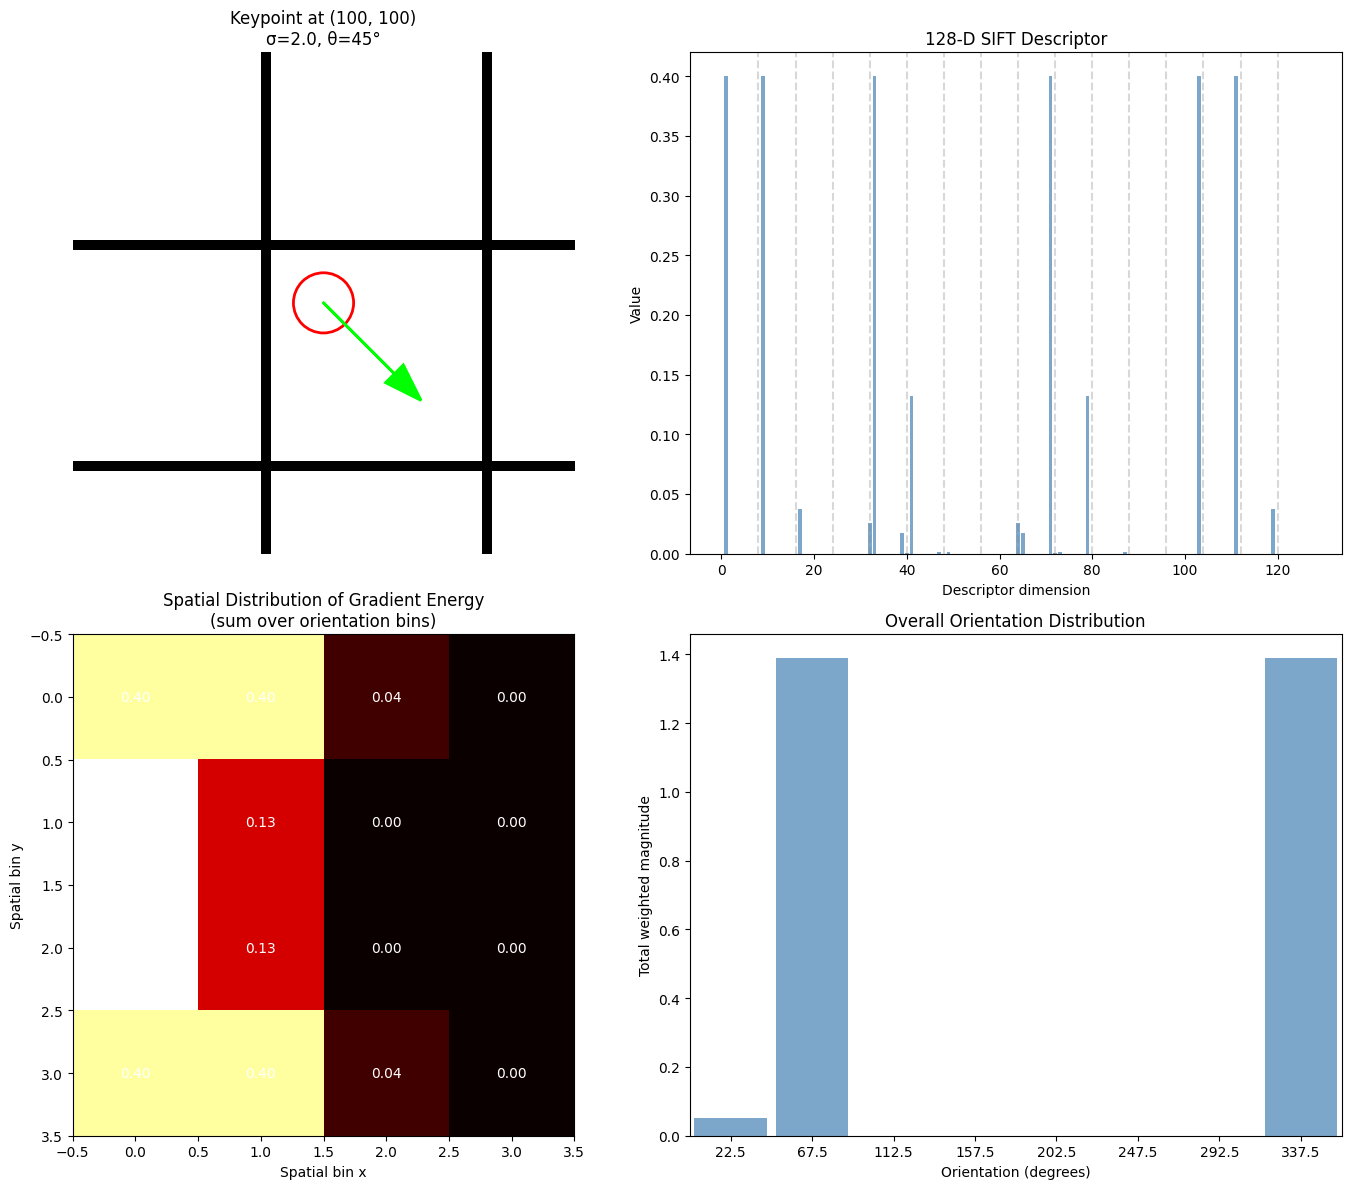

In [11]:
# Visualize the descriptor
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top left: keypoint location
axes[0, 0].imshow(img, cmap='gray')
circle = plt.Circle((kp_x, kp_y), kp_sigma * 3, fill=False, color='red', linewidth=2)
axes[0, 0].add_patch(circle)
theta = np.deg2rad(kp_orientation)
axes[0, 0].arrow(kp_x, kp_y, 20*np.cos(theta), 20*np.sin(theta),
                 head_width=5, fc='lime', ec='lime', linewidth=2)
axes[0, 0].set_xlim(kp_x - 50, kp_x + 50)
axes[0, 0].set_ylim(kp_y + 50, kp_y - 50)
axes[0, 0].set_title(f'Keypoint at ({kp_x}, {kp_y})\nσ={kp_sigma}, θ={kp_orientation}°')
axes[0, 0].axis('off')

# Top right: descriptor as 1D plot
axes[0, 1].bar(range(128), descriptor, color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('Descriptor dimension')
axes[0, 1].set_ylabel('Value')
axes[0, 1].set_title('128-D SIFT Descriptor')
# Add vertical lines to separate spatial bins
for i in range(1, 16):
    axes[0, 1].axvline(i * 8, color='gray', linestyle='--', alpha=0.3)

# Bottom left: descriptor as 4x4 grid of histograms
desc_2d = descriptor.reshape(4, 4, 8)
axes[1, 0].imshow(desc_2d.sum(axis=2), cmap='hot')
axes[1, 0].set_title('Spatial Distribution of Gradient Energy\n(sum over orientation bins)')
axes[1, 0].set_xlabel('Spatial bin x')
axes[1, 0].set_ylabel('Spatial bin y')
for i in range(4):
    for j in range(4):
        axes[1, 0].text(j, i, f'{desc_2d[i,j,:].sum():.2f}', 
                        ha='center', va='center', color='white', fontsize=10)

# Bottom right: orientation distribution (summed over all spatial bins)
ori_hist = desc_2d.sum(axis=(0, 1))
angles = np.arange(8) * 45 + 22.5
axes[1, 1].bar(angles, ori_hist, width=40, color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Orientation (degrees)')
axes[1, 1].set_ylabel('Total weighted magnitude')
axes[1, 1].set_title('Overall Orientation Distribution')
axes[1, 1].set_xticks(angles)
axes[1, 1].set_xlim(0, 360)

plt.tight_layout()
plt.show()

## 6. Testing Rotation Invariance

In [12]:
def rotate_image(image, angle_degrees):
    """Rotate image by angle_degrees around center."""
    center = (image.shape[1] // 2, image.shape[0] // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle_degrees, 1.0)
    return cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

def descriptor_distance(desc1, desc2):
    """Euclidean distance between two descriptors."""
    return np.linalg.norm(desc1 - desc2)

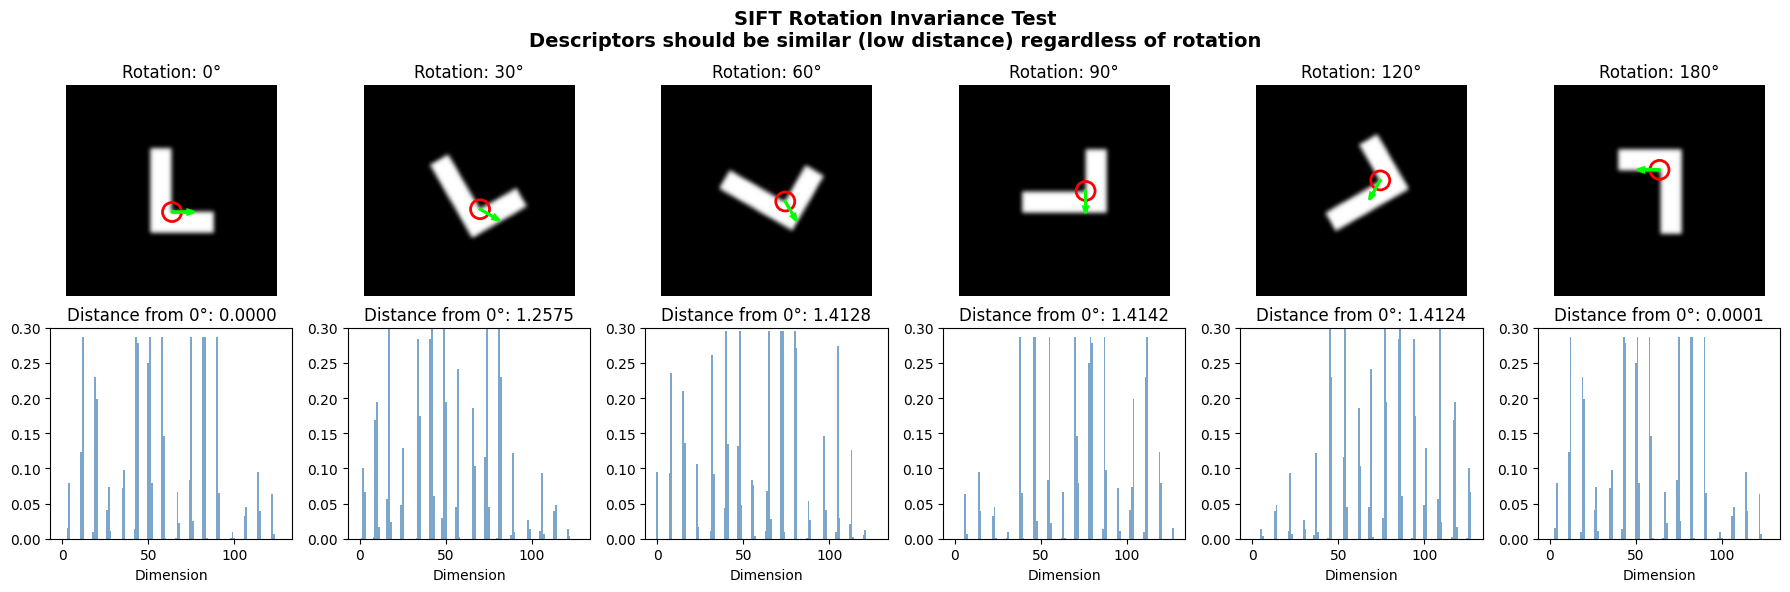


Descriptor distances from reference (0° rotation):
    0°: 0.0000
   30°: 1.2575
   60°: 1.4128
   90°: 1.4142
  120°: 1.4124
  180°: 0.0001


In [13]:
# Test rotation invariance
# Create a distinctive pattern
pattern_size = 200
pattern = np.zeros((pattern_size, pattern_size), dtype=np.float64)
# Add a distinctive L-shaped feature
pattern[60:140, 80:100] = 0.8  # Vertical bar
pattern[120:140, 80:140] = 0.8  # Horizontal bar
pattern = gaussian_blur(pattern, 2)

# Keypoint at the corner of the L
kp_x, kp_y = 100, 120
kp_sigma = 3.0

# Test different rotations
rotations = [0, 30, 60, 90, 120, 180]

fig, axes = plt.subplots(2, len(rotations), figsize=(18, 6))

reference_descriptor = None
distances = []

for i, angle in enumerate(rotations):
    # Rotate the image
    rotated = rotate_image((pattern * 255).astype(np.uint8), angle) / 255.0
    
    # Rotate the keypoint location around image center
    center = pattern_size // 2
    theta = np.deg2rad(-angle)  # Negative because image rotation is opposite
    new_kp_x = center + (kp_x - center) * np.cos(theta) - (kp_y - center) * np.sin(theta)
    new_kp_y = center + (kp_x - center) * np.sin(theta) + (kp_y - center) * np.cos(theta)
    
    # The keypoint orientation also rotates with the image
    # For this test, we'll use a fixed orientation relative to the feature
    # In practice, this comes from orientation assignment
    kp_orientation = angle  # Feature orientation rotates with image
    
    # Compute descriptor
    desc = compute_sift_descriptor(rotated, new_kp_x, new_kp_y, kp_sigma, kp_orientation)
    
    if reference_descriptor is None:
        reference_descriptor = desc
    
    dist = descriptor_distance(reference_descriptor, desc)
    distances.append(dist)
    
    # Visualize
    axes[0, i].imshow(rotated, cmap='gray')
    circle = plt.Circle((new_kp_x, new_kp_y), kp_sigma * 3, fill=False, color='red', linewidth=2)
    axes[0, i].add_patch(circle)
    t = np.deg2rad(kp_orientation)
    axes[0, i].arrow(new_kp_x, new_kp_y, 15*np.cos(t), 15*np.sin(t),
                     head_width=4, fc='lime', ec='lime', linewidth=2)
    axes[0, i].set_title(f'Rotation: {angle}°')
    axes[0, i].axis('off')
    
    # Descriptor visualization
    axes[1, i].bar(range(128), desc, color='steelblue', alpha=0.7, width=1)
    axes[1, i].set_ylim(0, 0.3)
    axes[1, i].set_title(f'Distance from 0°: {dist:.4f}')
    axes[1, i].set_xlabel('Dimension')

plt.suptitle('SIFT Rotation Invariance Test\n'
             'Descriptors should be similar (low distance) regardless of rotation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDescriptor distances from reference (0° rotation):")
for angle, dist in zip(rotations, distances):
    print(f"  {angle:3d}°: {dist:.4f}")

## 7. Summary: The Complete SIFT Algorithm

### The 4 Steps of SIFT

| Step | Purpose | Key Technique | Invariance |
|------|---------|---------------|------------|
| 1. Scale-Space | Find blobs at all scales | Gaussian pyramid + DoG | **Scale** |
| 2. Keypoint Localization | Refine positions, filter bad points | Taylor expansion, Hessian ratio | Accuracy |
| 3. Orientation Assignment | Assign canonical orientation | Gradient histogram | **Rotation** |
| 4. Descriptor | Create unique fingerprint | 4×4×8 histogram | Distinctiveness |

### Why SIFT Works So Well

1. **Scale invariance**: Same features found at any distance
2. **Rotation invariance**: Same features found at any angle
3. **Robust to noise**: Gaussian weighting, histogram smoothing
4. **Distinctive**: 128 dimensions capture rich local structure
5. **Compact**: Only 128 numbers per keypoint

### For Sudoku Detection

SIFT can help by:
1. Finding distinctive corners/junctions in the grid
2. Matching these to a template grid
3. Computing the homography from matched points
4. Warping the image to extract the grid

In [14]:
print("=" * 60)
print("SIFT IMPLEMENTATION COMPLETE!")
print("=" * 60)
print("\nFunctions created in this notebook series:")
print("\nNotebook 01 - Scale Space:")
print("  - gaussian_kernel_1d()")
print("  - gaussian_blur()")
print("  - build_gaussian_pyramid()")
print("  - build_dog_pyramid()")
print("  - find_dog_extrema()")
print("\nNotebook 02 - Keypoint Localization:")
print("  - compute_gradient_3d()")
print("  - compute_hessian_3d()")
print("  - localize_keypoint()")
print("  - filter_low_contrast()")
print("  - filter_edge_response()")
print("  - find_keypoints()")
print("\nNotebook 03 - Orientation:")
print("  - compute_gradients()")
print("  - compute_orientation_histogram()")
print("  - find_dominant_orientations()")
print("  - assign_orientations()")
print("\nNotebook 04 - Descriptor:")
print("  - rotate_point()")
print("  - trilinear_interpolation_weights()")
print("  - compute_sift_descriptor()")
print("\n" + "=" * 60)

SIFT IMPLEMENTATION COMPLETE!

Functions created in this notebook series:

Notebook 01 - Scale Space:
  - gaussian_kernel_1d()
  - gaussian_blur()
  - build_gaussian_pyramid()
  - build_dog_pyramid()
  - find_dog_extrema()

Notebook 02 - Keypoint Localization:
  - compute_gradient_3d()
  - compute_hessian_3d()
  - localize_keypoint()
  - filter_low_contrast()
  - filter_edge_response()
  - find_keypoints()

Notebook 03 - Orientation:
  - compute_gradients()
  - compute_orientation_histogram()
  - find_dominant_orientations()
  - assign_orientations()

Notebook 04 - Descriptor:
  - rotate_point()
  - trilinear_interpolation_weights()
  - compute_sift_descriptor()

